In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import adfuller

price_data = pd.read_csv("../data/prices.csv",
                         index_col = 0,
                         parse_dates = True).dropna()
price_data.head()

x = price_data["AAPL"]
y = price_data["MSFT"]

#x = np.log(price_data['AAPL'])
#y = np.log(price_data['MSFT'])
# Can use log returns, but still shows that they are NOT cointegrated ie the ADF test later on is not stationary

In [23]:
# Estimate hedge ratio β
X = add_constant(x)
model = OLS(y, X).fit()

beta = model.params[1]
print("Beta: ", beta)


Beta:  1.5453247979210674


C:\Users\yogst\AppData\Local\Temp\ipykernel_10904\3310645156.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta = model.params[1]


<function matplotlib.pyplot.show(close=None, block=None)>

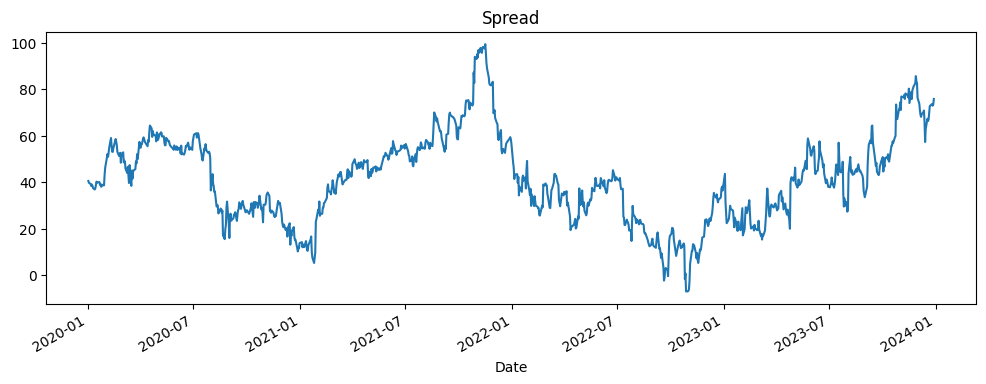

In [24]:
# Construct the spread 
spread = y - beta * x

spread.plot(figsize = (12,4))
plt.title("Spread")
plt.show

In [25]:
# Running a Augmented-Dickey Fuller test
result = adfuller(spread)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items(): # iterating through dictionary
    print(f"{key}: {value}")


ADF Statistic: -2.324654653009961
p-value: 0.16413959357425656
Critical Values:
1%: -3.436879978012783
5%: -2.86442302475405
10%: -2.568305057578451


### Interpretation of ADF test
We have that our p-value of 0.1641 > 0.05 (or that -2.32 < -2.86 so fail to reject null of a unit root), meaning our result is not significant and that we have a non-stationary time series/ pair is not cointegrated which means our mean reversion assumption was weak, and it explains the negative Sharpe values in day11.

(General meanings of p values:)
- If p < 0.05 -> spread is stationary -> cointegrated -> strategy structurally valid
- If p > 0.05 -> spread is non-stationary -> mean reversion assumption weak -> negative Sharpe expected

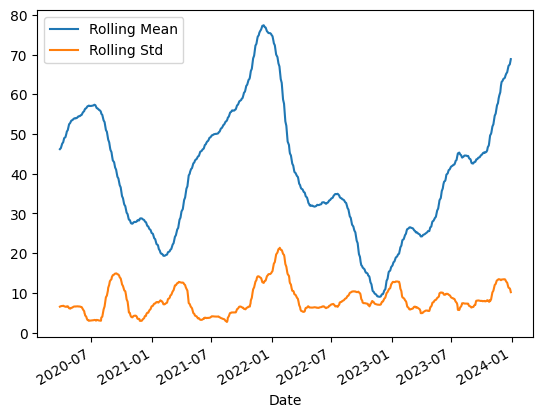

In [26]:
# Plot rolling mean and std
spread.rolling(60).mean().plot(label="Rolling Mean")
spread.rolling(60).std().plot(label="Rolling Std")
plt.legend()
plt.show()


In [27]:
# Testing for cointegration

from statsmodels.tsa.stattools import coint

score, pvalue, _ = coint(y, x)
print("Cointegration p-value:", pvalue)


Cointegration p-value: 0.36033093521793363


### Interpretation
Cointegration p-value is 0.36 > 0.05, hence we fail to reject H₀ since there is no statistical evidence of cointegration.
Hence there is no evidence that the linear combination of AAPL and MSFT is stationary.